# Vanilla GAN — A Simple Implementation

This notebook implements a **vanilla GAN** following the theory from Modules 4–6:

- **Module 4** — the minimax game

  $$\min_G \max_D V(D,G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- **Module 5** — alternating training of `D` and `G`, with `detach()` when training `D`.
- **Module 6** — practical realities. We use the non-saturating Generator loss to avoid the saturation problem mentioned there.

We train on **MNIST** because it is small, fast, and lets us visually verify the Generator's output.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

These follow common recommendations from the original DCGAN paper, which is a reasonable starting point for vanilla GANs.

In [2]:
# Hyperparameters
latent_dim   = 100    # z ~ N(0, I), shape (batch, 100)
img_channels = 1      # MNIST is grayscale
img_size     = 28
batch_size   = 64
lr           = 2e-4   # Adam learning rate
betas        = (0.5, 0.999)  # DCGAN-style betas
epochs       = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Folder for sample grids saved each epoch
os.makedirs('samples', exist_ok=True)

Using device: cpu


## 2. Data — MNIST

MNIST is 28×28 grayscale. We normalize to `[-1, +1]` so the Generator's final `Tanh` output matches the data range — a small but important detail for stable training.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),   # (0, 1) -> (-1, 1)
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

100.0%
100.0%
100.0%
100.0%


## 3. The Generator

The Generator maps a noise vector $z \sim \mathcal{N}(0, I)$ to an image:

$$G: \mathbb{R}^{100} \to \mathbb{R}^{28 \times 28}$$

Architectural choices:
- `LeakyReLU(0.2)` instead of `ReLU` to avoid dying ReLUs.
- `Tanh` on the output so values lie in $[-1, +1]$, matching our normalized MNIST.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_size=28):
        super().__init__()
        self.img_size = img_size
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, img_size * img_size),
            nn.Tanh(),
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, self.img_size, self.img_size)

## 4. The Discriminator

The Discriminator is a binary classifier:

$$D: \mathbb{R}^{28 \times 28} \to [0, 1]$$

It outputs the probability that an image is real. We use `Sigmoid` at the end and `BCELoss` for training.

- `Dropout(0.3)` helps prevent the Discriminator from becoming too confident too quickly (one of the issues from Module 6).
- We do **not** use BatchNorm in `D` — its real and fake inputs already have very different statistics, and BatchNorm would amplify that.

In [5]:
class Discriminator(nn.Module):
    def __init__(self, img_size=28):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(img_size * img_size, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        return self.model(img.view(img.size(0), -1))

## 5. Models, Optimizers, and Loss

Two separate Adam optimizers — one for `G`, one for `D`. Adam with `betas=(0.5, 0.999)` empirically works much better than SGD for GANs.

We use `BCELoss`, which is the negative of the GAN value function:

$$L_D = -[\log D(x) + \log(1 - D(G(z)))]$$

For the Generator we use the **non-saturating** loss:

$$L_G = -\mathbb{E}_z[\log D(G(z))]$$

instead of the theoretical $\log(1 - D(G(z)))$, because the latter saturates early when `D` is strong (Module 6).

In [6]:
G = Generator(latent_dim=latent_dim, img_size=img_size).to(device)
D = Discriminator(img_size=img_size).to(device)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

criterion = nn.BCELoss()

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256,

## 6. The Training Loop

Following **Module 5**, each iteration has two phases:

**Phase A — Train the Discriminator**

1. Sample real images `x`.
2. Sample noise `z`.
3. Generate fake images `G(z)` and **detach** them from `G`'s graph.
4. Compute `D(x)` and `D(G(z).detach())`.
5. BCE loss with targets `1` (real) and `0` (fake).
6. Backprop **only** into `D`.

**Phase B — Train the Generator**

1. Reuse the noise `z`.
2. Generate fake images — **no detach this time**.
3. Compute `D(G(z))`.
4. BCE loss with target `1` (we want `D` to think our fakes are real).
5. Backprop through `D` **and** into `G`. We update only `G`'s parameters.

In [7]:
fixed_noise = torch.randn(64, latent_dim, device=device)

losses_g = []
losses_d = []

G.train()
D.train()

for epoch in range(epochs):
    d_running_loss = 0.0
    g_running_loss = 0.0
    n_batches = 0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        valid = torch.ones(b, 1, device=device)
        fake   = torch.zeros(b, 1, device=device)

        # -----------------
        # Phase A: Train D
        # -----------------
        optimizer_D.zero_grad()

        # Real images -> label 1
        real_pred = D(real_imgs)
        d_real_loss = criterion(real_pred, valid)

        # Fake images -> label 0, detached so G receives no gradient
        z = torch.randn(b, latent_dim, device=device)
        with torch.no_grad():
            gen_imgs = G(z)
        fake_pred = D(gen_imgs)
        d_fake_loss = criterion(fake_pred, fake)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Phase B: Train G
        # -----------------
        optimizer_G.zero_grad()

        gen_imgs = G(z)               # NO detach — gradient flows through D into G
        validity = D(gen_imgs)
        g_loss = criterion(validity, valid)   # want D to label our fakes as real

        g_loss.backward()
        optimizer_G.step()

        d_running_loss += d_loss.item()
        g_running_loss += g_loss.item()
        n_batches += 1

    avg_d = d_running_loss / n_batches
    avg_g = g_running_loss / n_batches
    losses_d.append(avg_d)
    losses_g.append(avg_g)

    print(f"Epoch [{epoch+1}/{epochs}]  D: {avg_d:.4f}  G: {avg_g:.4f}")

    # Save a sample grid every epoch so we can watch the Generator improve
    G.eval()
    with torch.no_grad():
        sample_imgs = G(fixed_noise).detach().cpu()
    save_image(sample_imgs, f"samples/epoch_{epoch+1:02d}.png", nrow=8, normalize=True)
    G.train()

print('Training done.')

Epoch [1/20]  D: 0.3543  G: 2.5009
Epoch [2/20]  D: 0.3005  G: 2.7974
Epoch [3/20]  D: 0.2196  G: 2.7625
Epoch [4/20]  D: 0.2861  G: 2.3952
Epoch [5/20]  D: 0.3599  G: 1.9901
Epoch [6/20]  D: 0.4023  G: 1.7745
Epoch [7/20]  D: 0.4273  G: 1.6579
Epoch [8/20]  D: 0.4555  G: 1.5421
Epoch [9/20]  D: 0.4970  G: 1.3768
Epoch [10/20]  D: 0.5078  G: 1.3484
Epoch [11/20]  D: 0.5129  G: 1.3351
Epoch [12/20]  D: 0.5318  G: 1.2721
Epoch [13/20]  D: 0.5401  G: 1.2405
Epoch [14/20]  D: 0.5457  G: 1.2294
Epoch [15/20]  D: 0.5497  G: 1.2117
Epoch [16/20]  D: 0.5556  G: 1.1902
Epoch [17/20]  D: 0.5619  G: 1.1751
Epoch [18/20]  D: 0.5608  G: 1.1795
Epoch [19/20]  D: 0.5609  G: 1.1759
Epoch [20/20]  D: 0.5638  G: 1.1656
Training done.


## 7. Generating New Samples

After training, we can sample from the Generator by feeding it random noise. Each noise vector produces a different image. If training worked, these should look like MNIST digits.

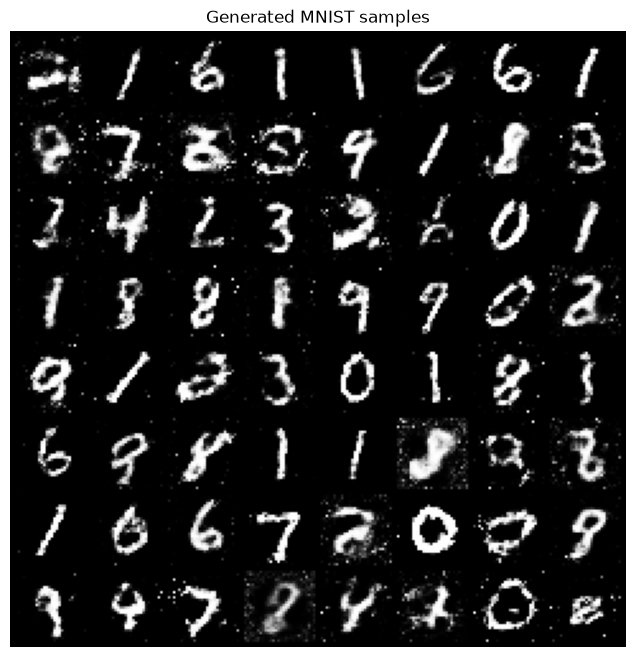

In [8]:
G.eval()
with torch.no_grad():
    samples = G(torch.randn(64, latent_dim, device=device)).cpu()

grid = make_grid(samples, nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated MNIST samples')
plt.show()

## 8. Training Progression

Each epoch we saved a grid of generated samples to the `samples/` folder. Reading them in order shows how the Generator improves over time.

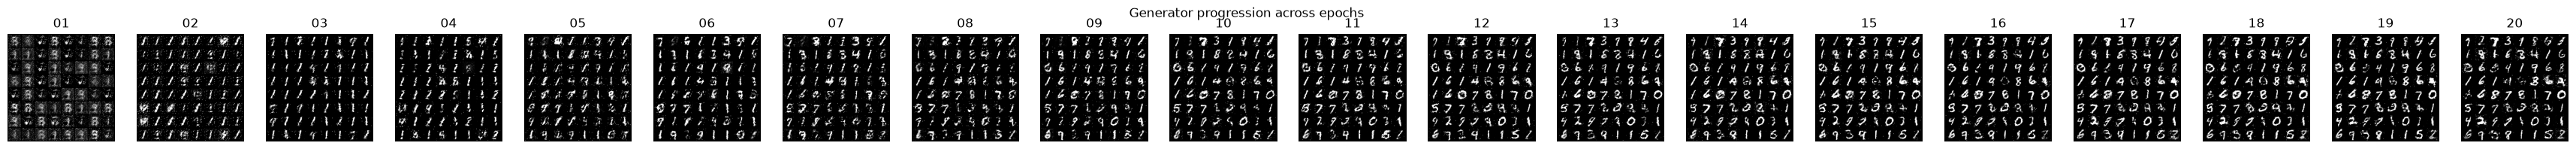

In [9]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(2.2 * len(paths), 2.2))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0])
        ax.axis('off')
    plt.suptitle('Generator progression across epochs')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

## 9. Loss Curves

As discussed in Module 6, raw GAN loss is hard to interpret on its own — but it can still reveal oscillation, collapse, or one network overpowering the other.

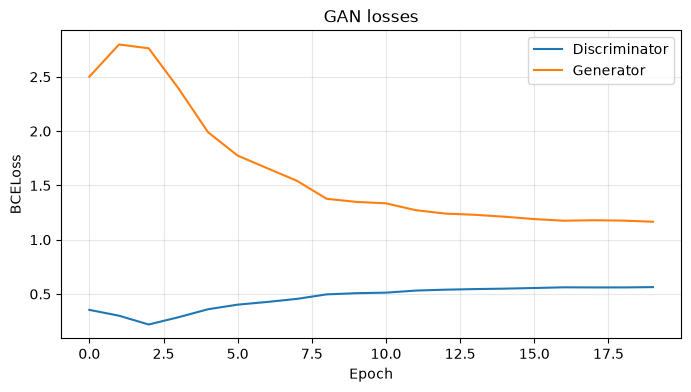

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(losses_d, label='Discriminator')
plt.plot(losses_g, label='Generator')
plt.xlabel('Epoch')
plt.ylabel('BCELoss')
plt.title('GAN losses')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Recap

You have now implemented a vanilla GAN. To connect it back to the theory:

- The **alternating update** of `D` and `G` is the practical realization of $\min_G \max_D V(D, G)$.
- The **`torch.no_grad()` block** during Phase A ensures only `D`'s weights are updated.
- **Gradients flow through `D` into `G`** during Phase B — this is the heart of GAN learning.
- The **non-saturating Generator loss** avoids the early-training saturation problem.
- `D(x) \approx 0.5` is the theoretical equilibrium (Module 4). Achieving it perfectly in practice is exactly the problem GAN research has spent years trying to solve.

**Next in the series**: improvements like deeper convolutional GANs, label smoothing, and one-sided label noise — each tackling one of the failure modes from Module 6.